In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats as scipy_stats
import statsmodels.formula.api as smf
from dotenv import load_dotenv

load_dotenv(Path('..') / '.env')
sys.path.insert(0, str(Path('.')))

from ab_testing.stats import cuped, welch_t_test

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

In [2]:
# Constants and config
DATA_DIR = Path('..') / 'data' / 'synthetic'
ALPHA    = 0.05
SEED     = 42
rng      = np.random.default_rng(SEED)

# CUPED: Controlled-experiment Using Pre-Experiment Data

**Reference**: Deng et al. (2013), *Improving the Sensitivity of Online Controlled Experiments by Utilizing Pre-Experiment Data*, KDD.

This notebook covers four topics:

| Part | Topic |
|------|-------|
| 1 | CUPED mechanics: the math and why it works |
| 2 | Sample size reduction: variance reduction → smaller experiments |
| 3 | CUPED vs regression adjustment (ANCOVA): when they agree and when they differ |
| 4 | Correcting randomization imbalance: CUPED as a bias-correction tool |

---

## Part 1 — CUPED: The Mechanics

### The core idea

In an A/B test, the metric you care about — say, revenue per user in the experiment period — has two sources of variance:
1. **Signal**: variance caused by the treatment
2. **Noise**: variance from user heterogeneity that existed *before* the experiment

If user A spends \\$50 per month  and user B spends \\$5 per month, that difference will show up in experiment outcomes regardless of which variant they saw. CUPED removes this pre-existing noise using pre-experiment data.

### The math

Let $Y_i$ be the post-experiment metric and $X_i$ be any pre-experiment covariate (e.g., revenue in the prior 30 days). CUPED defines the adjusted metric:

$$\tilde{Y}_i = Y_i - \theta (X_i - \mathbb{E}[X])$$

The coefficient $\theta$ is chosen to **minimize variance of $\tilde{Y}$**:

$$\theta^* = \frac{\text{Cov}(Y, X)}{\text{Var}(X)}$$

This is exactly the OLS slope of regressing $Y$ on $X$. With this $\theta$:

$$\text{Var}(\tilde{Y}) = \text{Var}(Y) \cdot (1 - \rho_{XY}^2)$$

**Variance reduction = $\rho^2$**, the squared correlation between pre- and post-experiment metrics.

### Why the treatment effect is preserved

Because $X$ is pre-experiment and thus **independent of treatment assignment**:

$$\mathbb{E}[\tilde{Y}_T] - \mathbb{E}[\tilde{Y}_C] = \mathbb{E}[Y_T] - \mathbb{E}[Y_C] - \theta \underbrace{(\mathbb{E}[X_T] - \mathbb{E}[X_C])}_{=\, 0 \text{ by randomization}}$$

So the expected treatment effect is identical before and after adjustment. We reduce variance without introducing bias.

### Critical implementation detail

$\theta$ must be estimated from **pooled pre-experiment data** (or from a held-out dataset). Estimating it per-group would induce correlation between the estimator and treatment assignment, causing bias.

In [3]:
# Simulate a clean experiment: pre-period revenue strongly predicts post-period revenue
# True treatment effect: +$5 revenue per user

N_PER_ARM    = 500
TRUE_EFFECT  = 5.0
RHO          = 0.75   # correlation between pre and post

# Pre-experiment revenue: shared user-level trait (e.g., engagement tier)
user_baseline = rng.lognormal(mean=3.5, sigma=0.8, size=N_PER_ARM * 2)   # heterogeneous users

# Post-experiment revenue = f(baseline) + noise + [treatment effect for treatment arm]
noise = rng.normal(0, user_baseline.std() * np.sqrt(1 - RHO**2) / RHO, size=N_PER_ARM * 2)
post  = RHO * user_baseline + noise

pre_ctrl   = user_baseline[:N_PER_ARM]
pre_treat  = user_baseline[N_PER_ARM:]
post_ctrl  = post[:N_PER_ARM]
post_treat = post[N_PER_ARM:] + TRUE_EFFECT   # inject treatment effect

# Compute theta from pooled data
all_pre  = np.concatenate([pre_ctrl, pre_treat])
all_post = np.concatenate([post_ctrl, post_treat])
theta    = np.cov(all_post, all_pre)[0, 1] / np.var(all_pre)
pre_mean = all_pre.mean()

ctrl_adj  = post_ctrl  - theta * (pre_ctrl  - pre_mean)
treat_adj = post_treat - theta * (pre_treat - pre_mean)

var_raw   = all_post.var()
var_cuped = np.concatenate([ctrl_adj, treat_adj]).var()
rho_actual = np.corrcoef(all_post, all_pre)[0, 1]

print(f'Empirical correlation (rho)   : {rho_actual:.3f}')
print(f'Theta                         : {theta:.4f}')
print(f'Variance before CUPED         : {var_raw:.2f}')
print(f'Variance after  CUPED         : {var_cuped:.2f}')
print(f'Variance reduction (actual)   : {1 - var_cuped/var_raw:.1%}')
print(f'Variance reduction (rho^2)    : {rho_actual**2:.1%}  <- predicted by theory')

Empirical correlation (rho)   : 0.638
Theta                         : 0.7389
Variance before CUPED         : 2200.72
Variance after  CUPED         : 1305.71
Variance reduction (actual)   : 40.7%
Variance reduction (rho^2)    : 40.7%  <- predicted by theory


In [4]:
# Run both tests
raw_result   = welch_t_test(post_ctrl, post_treat, alpha=ALPHA)
cuped_result = cuped(post_ctrl, post_treat, pre_ctrl, pre_treat, alpha=ALPHA)

print('Without CUPED:', raw_result)
print('With    CUPED:', cuped_result)

Without CUPED: welch_t_test: effect=-0.7276 [-6.5555, 5.1002], p=0.8065 (not significant at α=0.05)
With    CUPED: cuped: effect=-0.5397 [-5.0287, 3.9493], p=0.8136 (not significant at α=0.05)


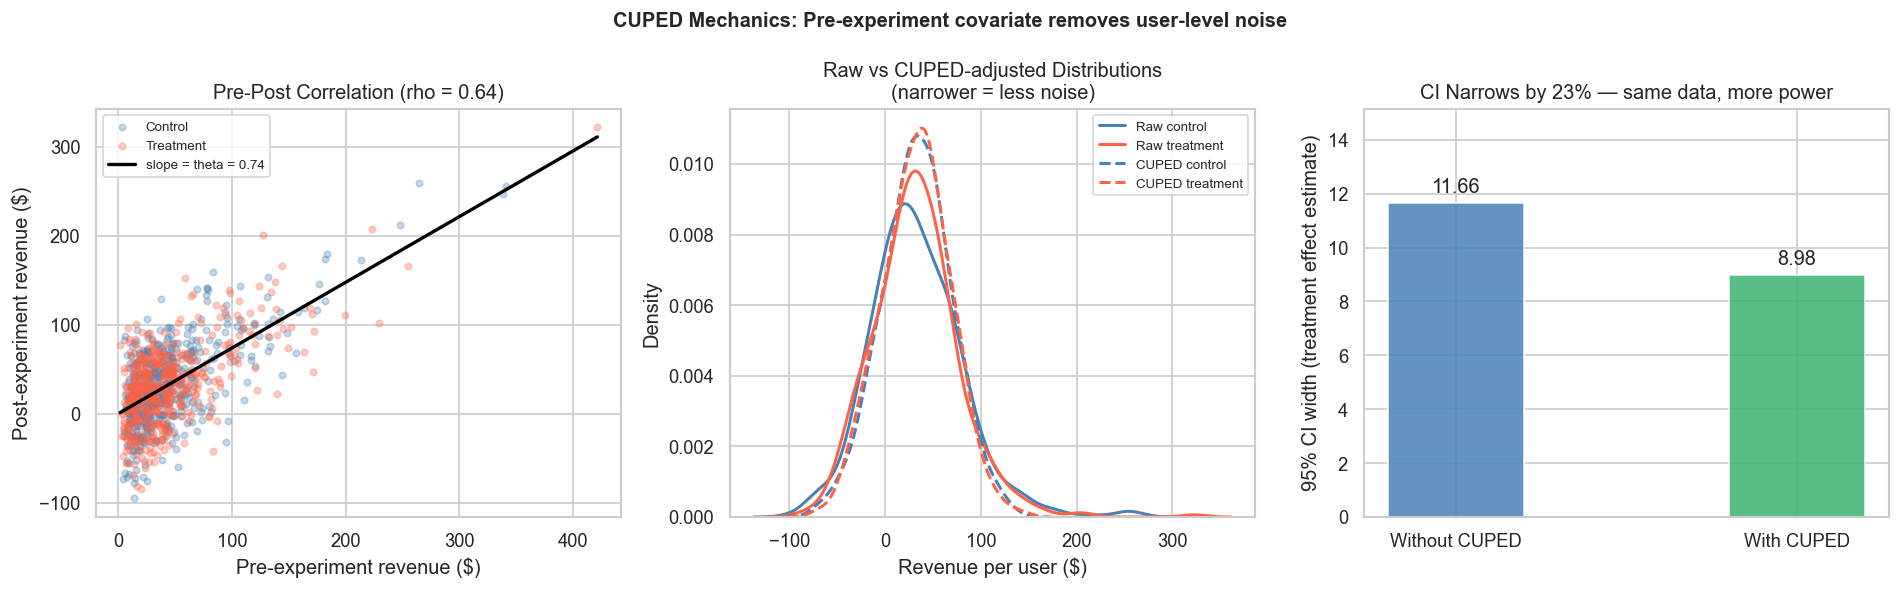

In [5]:
# Visualise the adjustment: scatter of pre vs post, and distribution comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Panel A: Pre vs Post scatter (shows the variance we can explain) ---
ax = axes[0]
ax.scatter(pre_ctrl,  post_ctrl,  alpha=0.3, s=15, color='steelblue', label='Control')
ax.scatter(pre_treat, post_treat, alpha=0.3, s=15, color='tomato',    label='Treatment')
x_line = np.linspace(all_pre.min(), all_pre.max(), 100)
ax.plot(x_line, theta * (x_line - pre_mean) + all_post.mean(),
        color='black', linewidth=2, label=f'slope = theta = {theta:.2f}')
ax.set_xlabel('Pre-experiment revenue ($)')
ax.set_ylabel('Post-experiment revenue ($)')
ax.set_title(f'Pre-Post Correlation (rho = {rho_actual:.2f})')
ax.legend(fontsize=8)

# --- Panel B: Raw vs adjusted outcome distributions ---
ax = axes[1]
for series, color, ls, label in [
    (post_ctrl,  'steelblue', '-',  'Raw control'),
    (post_treat, 'tomato',    '-',  'Raw treatment'),
    (ctrl_adj,   'steelblue', '--', 'CUPED control'),
    (treat_adj,  'tomato',    '--', 'CUPED treatment'),
]:
    sns.kdeplot(series, ax=ax, color=color, linestyle=ls, label=label, linewidth=1.8)
ax.set_xlabel('Revenue per user ($)')
ax.set_title('Raw vs CUPED-adjusted Distributions\n(narrower = less noise)')
ax.legend(fontsize=8)

# --- Panel C: CI width comparison ---
ax = axes[2]
raw_w   = raw_result.ci_upper   - raw_result.ci_lower
cuped_w = cuped_result.ci_upper - cuped_result.ci_lower
methods = ['Without CUPED', 'With CUPED']
widths  = [raw_w, cuped_w]
colors  = ['steelblue', 'mediumseagreen']
bars    = ax.bar(methods, widths, color=colors, alpha=0.85, width=0.4)
ax.bar_label(bars, fmt='%.2f', padding=4)
ax.set_ylabel('95% CI width (treatment effect estimate)')
ax.set_title(f'CI Narrows by {1 - cuped_w/raw_w:.0%} — same data, more power')
ax.set_ylim(0, max(widths) * 1.3)

fig.suptitle('CUPED Mechanics: Pre-experiment covariate removes user-level noise',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Part 2 — Variance Reduction Translates Directly to Sample Size Savings

The required sample size for a t-test scales with the variance of the outcome:

$$n \propto \frac{\sigma^2}{\delta^2}$$

Since CUPED reduces variance by a factor of $(1 - \rho^2)$, the required sample size shrinks by the same factor:

$$n_{\text{CUPED}} = n_{\text{naive}} \cdot (1 - \rho^2)$$

| $\rho$ (pre-post correlation) | Variance reduction | Sample size reduction |
|------------------------------|-------------------|----------------------|
| 0.3 | 9% | 9% |
| 0.5 | 25% | 25% |
| 0.7 | 49% | 49% |
| 0.8 | 64% | 64% |
| 0.9 | 81% | 81% |

In SaaS products, the 7-day pre-period revenue is often correlated at $\rho \approx 0.6$–$0.8$ with the experiment-period revenue — giving 36%–64% sample size reduction for free.

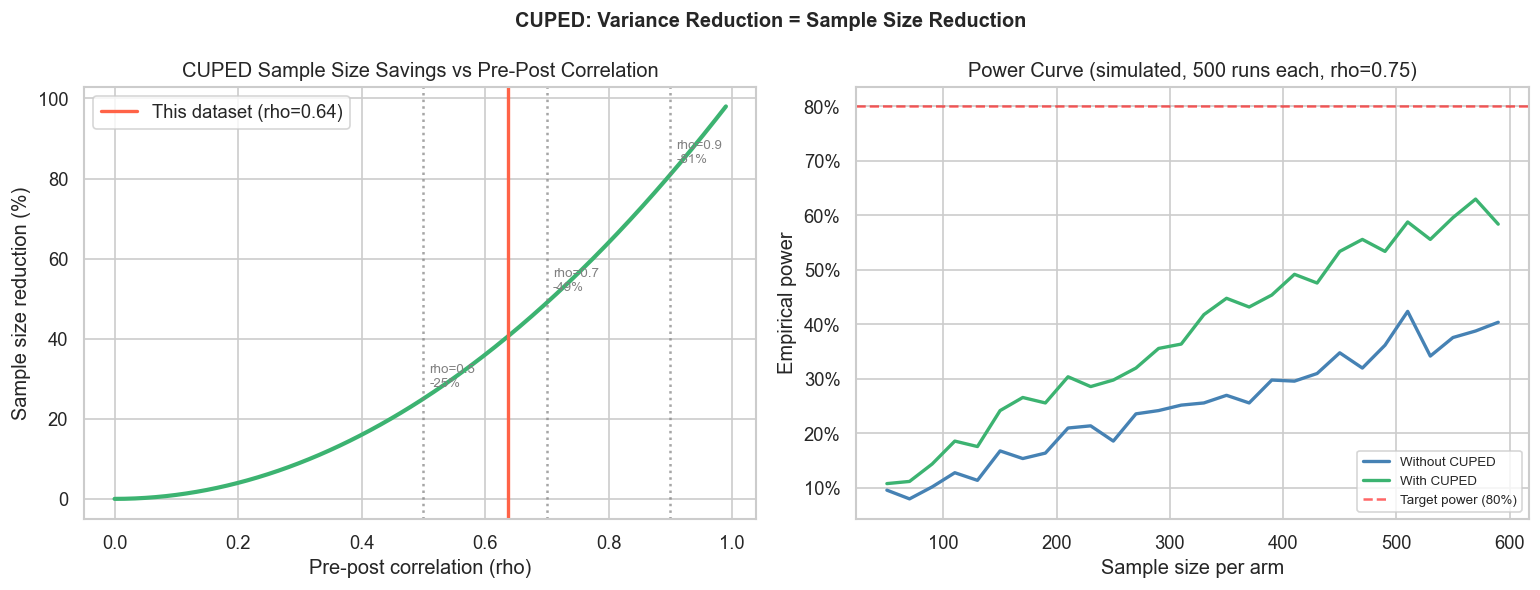


Theoretical sample size multiplier at rho=0.75: 0.44x
Extend n_range to see both methods reach 80% power within the plotted range.


In [12]:
# Theoretical sample size reduction as a function of rho
rhos = np.linspace(0, 0.99, 300)
reduction_pct = rhos**2 * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel A: variance reduction vs rho
ax = axes[0]
ax.plot(rhos, reduction_pct, linewidth=2.5, color='mediumseagreen')
for rho_mark, label_y in [(0.5, 25), (0.7, 49), (0.9, 81)]:
    ax.axvline(rho_mark, color='gray', linestyle=':', alpha=0.7)
    ax.text(rho_mark + 0.01, label_y + 3, f'rho={rho_mark}\n-{rho_mark**2:.0%}',
            fontsize=8, color='gray')
ax.axvline(rho_actual, color='tomato', linewidth=2, label=f'This dataset (rho={rho_actual:.2f})')
ax.set_xlabel('Pre-post correlation (rho)')
ax.set_ylabel('Sample size reduction (%)')
ax.set_title('CUPED Sample Size Savings vs Pre-Post Correlation')
ax.legend()

# Panel B: power simulation — CUPED vs naive at various n
ax = axes[1]
n_range = np.arange(50, 600, 20)
power_raw   = []
power_cuped = []

N_SIMS = 500
rng_pow = np.random.default_rng(123)

for n in n_range:
    sig_raw = sig_cup = 0
    for _ in range(N_SIMS):
        base = rng_pow.lognormal(3.5, 0.8, n * 2)
        noise_ = rng_pow.normal(0, base.std() * np.sqrt(1 - RHO**2) / RHO, n * 2)
        post_  = RHO * base + noise_
        pc, pt = post_[:n], post_[n:] + TRUE_EFFECT
        xc, xt = base[:n], base[n:]

        r_raw = welch_t_test(pc, pt, alpha=ALPHA)
        r_cup = cuped(pc, pt, xc, xt, alpha=ALPHA)
        sig_raw += r_raw.significant
        sig_cup += r_cup.significant
    power_raw.append(sig_raw / N_SIMS)
    power_cuped.append(sig_cup / N_SIMS)

ax.plot(n_range, power_raw,   linewidth=2, color='steelblue',      label='Without CUPED')
ax.plot(n_range, power_cuped, linewidth=2, color='mediumseagreen', label='With CUPED')
ax.axhline(0.80, color='red', linestyle='--', alpha=0.6, label='Target power (80%)')

p_arr_r = np.array(power_raw)
p_arr_c = np.array(power_cuped)
n_raw_80   = n_range[np.argmax(p_arr_r >= 0.80)] if (p_arr_r >= 0.80).any() else None
n_cuped_80 = n_range[np.argmax(p_arr_c >= 0.80)] if (p_arr_c >= 0.80).any() else None

if n_raw_80 is not None:
    ax.axvline(n_raw_80,   color='steelblue',      linestyle=':', label=f'n={n_raw_80} (raw)')
if n_cuped_80 is not None:
    ax.axvline(n_cuped_80, color='mediumseagreen', linestyle=':', label=f'n={n_cuped_80} (CUPED)')

ax.set_xlabel('Sample size per arm')
ax.set_ylabel('Empirical power')
ax.set_title(f'Power Curve (simulated, {N_SIMS} runs each, rho={RHO})')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(fontsize=8)

plt.suptitle('CUPED: Variance Reduction = Sample Size Reduction', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nTheoretical sample size multiplier at rho={RHO}: {1 - RHO**2:.2f}x')
if n_raw_80 is not None and n_cuped_80 is not None:
    print(f'Simulated: raw needs ~{n_raw_80} per arm, CUPED needs ~{n_cuped_80} per arm')
    print(f'Observed reduction: {1 - n_cuped_80/n_raw_80:.1%}')
else:
    print('Extend n_range to see both methods reach 80% power within the plotted range.')


---
## Part 3 — CUPED vs Regression Adjustment (ANCOVA)

Both methods use the pre-experiment covariate to reduce variance. Their relationship is subtle and often confused.

### CUPED
1. Compute adjusted outcomes: $\tilde{Y}_i = Y_i - \hat{\theta}(X_i - \bar{X})$
2. Run a standard t-test on $\tilde{Y}_T$ vs $\tilde{Y}_C$

### ANCOVA (regression adjustment)
Fit a single OLS model:
$$Y_i = \alpha + \tau \cdot \text{Treatment}_i + \beta \cdot X_i + \varepsilon_i$$
and read off $\hat{\tau}$ as the treatment effect.

### When are they identical?

When groups are **perfectly balanced** (equal $n$ per arm and equal covariate means by construction — as in proper randomization), CUPED and ANCOVA give the **same point estimate** for the treatment effect. The standard errors differ slightly because:

- **CUPED** uses the variance of $\tilde{Y}$ and a standard t-test SE formula
- **ANCOVA** uses residual variance from the OLS fit, which also accounts for estimating $\beta$

In large samples, both SEs converge. In small samples, ANCOVA SEs are slightly more conservative (uses $n - 3$ df instead of $n - 2$).

### The key difference

| Property | CUPED | ANCOVA |
|----------|-------|--------|
| Point estimate | Identical (when balanced) | Identical (when balanced) |
| Standard error | Slightly optimistic | Slightly conservative (correct df) |
| With **imbalanced** groups | Adjusts means; see Part 4 | Adjusts conditional on X; similar |
| Multiple covariates | Natural extension | Natural (add more regressors) |
| Composable | Yes — pre-process, then test with any method | Tightly coupled to OLS |
| Assumption | $\theta$ estimated from pooled data | Homogeneous slope across groups |

**CUPED is modular**: once you have $\tilde{Y}$, you can run any test — bootstrap, Mann-Whitney, sequential test — on the adjusted outcomes. With ANCOVA, you're locked into the linear model.

**Both assume a linear relationship** between $X$ and $Y$. If the relationship is nonlinear (e.g., log-revenue vs revenue), transform $X$ before applying either method.

In [7]:
# Compare CUPED and ANCOVA side-by-side on the same dataset

df = pd.DataFrame({
    'Y':         np.concatenate([post_ctrl, post_treat]),
    'X':         np.concatenate([pre_ctrl,  pre_treat]),
    'treatment': np.repeat([0, 1], N_PER_ARM).astype(float),
})

# CUPED (our library)
r_cuped = cuped(post_ctrl, post_treat, pre_ctrl, pre_treat, alpha=ALPHA)

# ANCOVA via OLS: Y ~ treatment + X
ols_model = smf.ols('Y ~ treatment + X', data=df).fit()
tau_ols   = ols_model.params['treatment']
se_ols    = ols_model.bse['treatment']
p_ols     = ols_model.pvalues['treatment']
ci_ols    = ols_model.conf_int(alpha=ALPHA).loc['treatment']

# Unadjusted t-test
r_raw = welch_t_test(post_ctrl, post_treat, alpha=ALPHA)

print('True treatment effect :', TRUE_EFFECT)
print()
print(f'{"Method":<22} {"Est. effect":>12} {"95% CI":<22} {"p-value":>10} {"Significant":>12}')
print('-' * 82)
print(f'{"Unadjusted t-test":<22} {r_raw.effect_size:>12.4f}  '
      f'[{r_raw.ci_lower:.4f}, {r_raw.ci_upper:.4f}]  '
      f'{r_raw.p_value:>10.4f}  {str(r_raw.significant):>12}')
print(f'{"CUPED (ours)":<22} {r_cuped.effect_size:>12.4f}  '
      f'[{r_cuped.ci_lower:.4f}, {r_cuped.ci_upper:.4f}]  '
      f'{r_cuped.p_value:>10.4f}  {str(r_cuped.significant):>12}')
print(f'{"ANCOVA (OLS)":<22} {tau_ols:>12.4f}  '
      f'[{ci_ols[0]:.4f}, {ci_ols[1]:.4f}]  '
      f'{p_ols:>10.4f}  {str(p_ols < ALPHA):>12}')

print()
print('OLS beta for X (= theta):   ', ols_model.params['X'])
print('CUPED theta (pooled cov/var):', theta)

True treatment effect : 5.0

Method                  Est. effect 95% CI                    p-value  Significant
----------------------------------------------------------------------------------
Unadjusted t-test           -0.7276  [-6.5555, 5.1002]      0.8065         False
CUPED (ours)                -0.5397  [-5.0287, 3.9493]      0.8136         False
ANCOVA (OLS)                -0.5397  [-5.0310, 3.9516]      0.8136         False

OLS beta for X (= theta):    0.7381835862194754
CUPED theta (pooled cov/var): 0.7389434485296117


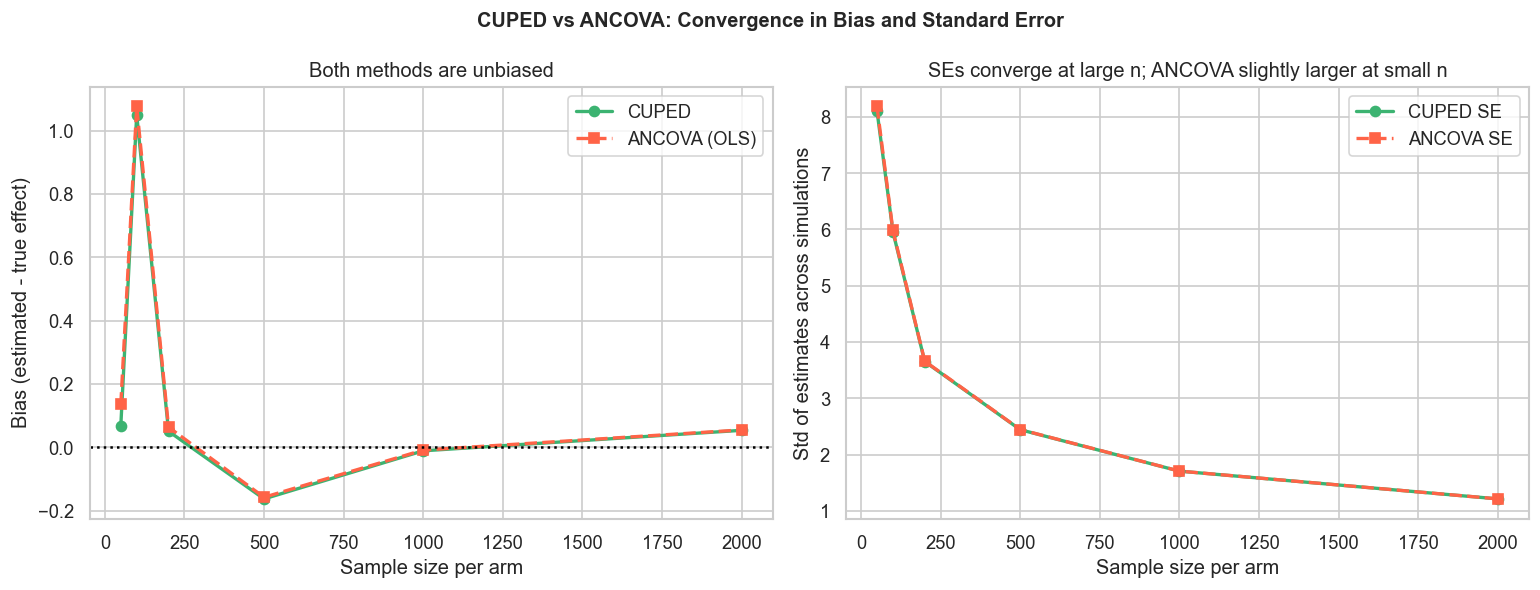

In [8]:
# Show they converge as n grows: simulated point estimates from both methods
ns_sim   = [50, 100, 200, 500, 1000, 2000]
N_TRIALS = 300
rng_conv = np.random.default_rng(7)

cuped_bias = []
ols_bias   = []
cuped_se   = []
ols_se_    = []

for n in ns_sim:
    cuped_ests, ols_ests = [], []
    for _ in range(N_TRIALS):
        base_ = rng_conv.lognormal(3.5, 0.8, n * 2)
        noise_ = rng_conv.normal(0, base_.std() * np.sqrt(1 - RHO**2) / RHO, n * 2)
        post_  = RHO * base_ + noise_
        pc_, pt_ = post_[:n], post_[n:] + TRUE_EFFECT
        xc_, xt_ = base_[:n], base_[n:]

        # CUPED estimate = mean difference of adjusted outcomes
        ap_ = np.concatenate([pc_, pt_])
        ax_ = np.concatenate([xc_, xt_])
        th_ = np.cov(ap_, ax_)[0, 1] / np.var(ax_)
        xm_ = ax_.mean()
        cuped_ests.append((pt_ - th_ * (xt_ - xm_)).mean() - (pc_ - th_ * (xc_ - xm_)).mean())

        # ANCOVA estimate
        df_ = pd.DataFrame({'Y': np.concatenate([pc_, pt_]),
                            'X': np.concatenate([xc_, xt_]),
                            'T': np.repeat([0, 1], n).astype(float)})
        ols_ests.append(smf.ols('Y ~ T + X', data=df_).fit().params['T'])

    cuped_bias.append(np.mean(cuped_ests) - TRUE_EFFECT)
    ols_bias.append(np.mean(ols_ests) - TRUE_EFFECT)
    cuped_se.append(np.std(cuped_ests))
    ols_se_.append(np.std(ols_ests))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(ns_sim, cuped_bias, marker='o', linewidth=2, color='mediumseagreen', label='CUPED')
ax.plot(ns_sim, ols_bias,   marker='s', linewidth=2, color='tomato',         label='ANCOVA (OLS)', linestyle='--')
ax.axhline(0, color='black', linestyle=':', linewidth=1.5)
ax.set_xlabel('Sample size per arm')
ax.set_ylabel('Bias (estimated - true effect)')
ax.set_title('Both methods are unbiased')
ax.legend()

ax = axes[1]
ax.plot(ns_sim, cuped_se, marker='o', linewidth=2, color='mediumseagreen', label='CUPED SE')
ax.plot(ns_sim, ols_se_,  marker='s', linewidth=2, color='tomato',         label='ANCOVA SE', linestyle='--')
ax.set_xlabel('Sample size per arm')
ax.set_ylabel('Std of estimates across simulations')
ax.set_title('SEs converge at large n; ANCOVA slightly larger at small n')
ax.legend()

fig.suptitle('CUPED vs ANCOVA: Convergence in Bias and Standard Error', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Part 4 — Correcting Randomization Imbalance

Even with proper randomization, covariate imbalance can occur by chance — especially in small experiments. For example, the treatment arm may happen to contain more high-revenue users.

This imbalance inflates (or deflates) the naive treatment effect estimate:

$$\hat{\tau}_{\text{naive}} = \underbrace{(\bar{Y}_T - \bar{Y}_C)}_{\text{true effect}} + \underbrace{\hat{\theta}(\bar{X}_T - \bar{X}_C)}_{\text{imbalance bias}}$$

CUPED removes this imbalance term by subtracting $\hat{\theta}(X_i - \bar{X})$ from each observation. The adjusted group means no longer reflect the pre-existing heterogeneity:

$$\hat{\tau}_{\text{CUPED}} = (\bar{\tilde{Y}}_T - \bar{\tilde{Y}}_C) = (\bar{Y}_T - \bar{Y}_C) - \hat{\theta}(\bar{X}_T - \bar{X}_C) \approx \tau$$

**This is not the primary use case of CUPED** (variance reduction is), but it is a useful side effect. In practice, the bias from randomization imbalance is usually small with $n \geq 200$, but can matter in:
- Holdout experiments with stratified assignment
- Switchback (time-based) experiments where carry-over is an issue
- Small-n pilot experiments

In [9]:
# Simulate randomization imbalance
# Scenario: treatment arm ended up with systematically higher pre-period revenue
# (could happen in small experiments or imperfect stratification)

rng_imb = np.random.default_rng(999)

N_IMB         = 120   # small experiment -> more susceptible to imbalance
TRUE_EFFECT   = 5.0
IMBALANCE_USD = 20.0  # treatment arm had $20 higher pre-period revenue by chance

# Generate users
pre_all = rng_imb.lognormal(3.5, 0.8, N_IMB * 2)

# Inject imbalance: treatment arm's pre-period is shifted up by $20
pre_ctrl_imb  = pre_all[:N_IMB]
pre_treat_imb = pre_all[N_IMB:] + IMBALANCE_USD

# Post-period revenue based on pre-period
noise_imb  = rng_imb.normal(0, pre_all.std() * np.sqrt(1 - RHO**2) / RHO, N_IMB * 2)
post_ctrl_imb  = RHO * pre_ctrl_imb  + noise_imb[:N_IMB]
post_treat_imb = RHO * pre_treat_imb + noise_imb[N_IMB:] + TRUE_EFFECT

r_raw_imb   = welch_t_test(post_ctrl_imb, post_treat_imb, alpha=ALPHA)
r_cuped_imb = cuped(post_ctrl_imb, post_treat_imb, pre_ctrl_imb, pre_treat_imb, alpha=ALPHA)

# Also ANCOVA
df_imb = pd.DataFrame({
    'Y': np.concatenate([post_ctrl_imb, post_treat_imb]),
    'X': np.concatenate([pre_ctrl_imb,  pre_treat_imb]),
    'T': np.repeat([0, 1], N_IMB).astype(float),
})
ols_imb = smf.ols('Y ~ T + X', data=df_imb).fit()

pre_diff = pre_treat_imb.mean() - pre_ctrl_imb.mean()
print(f'Pre-experiment mean difference (imbalance): ${pre_diff:.2f}')
print(f'True treatment effect                      : ${TRUE_EFFECT:.2f}')
print()
print(f'Naive t-test estimate  : {r_raw_imb.effect_size:+.2f}   (bias = {r_raw_imb.effect_size - TRUE_EFFECT:+.2f})')
print(f'CUPED estimate         : {r_cuped_imb.effect_size:+.2f}   (bias = {r_cuped_imb.effect_size - TRUE_EFFECT:+.2f})')
print(f'ANCOVA estimate        : {ols_imb.params["T"]:+.2f}   (bias = {ols_imb.params["T"] - TRUE_EFFECT:+.2f})')

Pre-experiment mean difference (imbalance): $16.18
True treatment effect                      : $5.00

Naive t-test estimate  : +11.15   (bias = +6.15)
CUPED estimate         : -0.02   (bias = -5.02)
ANCOVA estimate        : -0.02   (bias = -5.02)


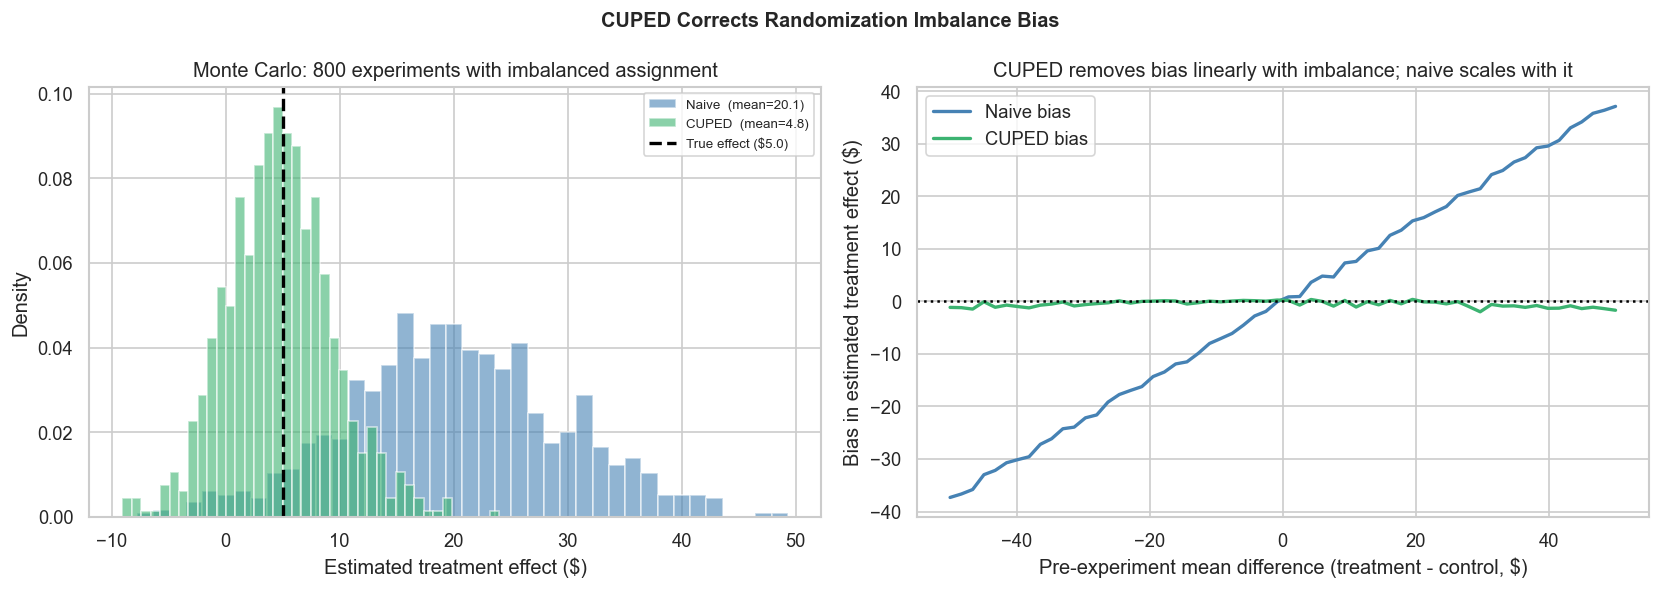


Mean bias — Naive: +15.14$
Mean bias — CUPED: -0.21$


In [10]:
# Monte Carlo: bias distribution across many imbalanced experiments
N_MC    = 800
rng_mc  = np.random.default_rng(2024)
N_MC_N  = 120

raw_ests, cuped_ests_mc = [], []

for _ in range(N_MC):
    pre_b = rng_mc.lognormal(3.5, 0.8, N_MC_N * 2)
    # Imbalance: shift treatment pre by a random amount drawn from N(20, 10)
    shift = rng_mc.normal(IMBALANCE_USD, 10.0)
    pre_c = pre_b[:N_MC_N]
    pre_t = pre_b[N_MC_N:] + shift
    nz    = rng_mc.normal(0, pre_b.std() * np.sqrt(1 - RHO**2) / RHO, N_MC_N * 2)
    post_c = RHO * pre_c + nz[:N_MC_N]
    post_t = RHO * pre_t + nz[N_MC_N:] + TRUE_EFFECT

    raw_ests.append(welch_t_test(post_c, post_t).effect_size)

    all_p = np.concatenate([post_c, post_t])
    all_x = np.concatenate([pre_c, pre_t])
    th    = np.cov(all_p, all_x)[0, 1] / np.var(all_x)
    xm    = all_x.mean()
    cuped_ests_mc.append(
        (post_t - th * (pre_t - xm)).mean() - (post_c - th * (pre_c - xm)).mean()
    )

raw_ests   = np.array(raw_ests)
cuped_ests_mc = np.array(cuped_ests_mc)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: distribution of estimates
ax = axes[0]
ax.hist(raw_ests,      bins=40, alpha=0.6, color='steelblue',      label=f'Naive  (mean={raw_ests.mean():.1f})', density=True)
ax.hist(cuped_ests_mc, bins=40, alpha=0.6, color='mediumseagreen', label=f'CUPED  (mean={cuped_ests_mc.mean():.1f})', density=True)
ax.axvline(TRUE_EFFECT, color='black', linewidth=2, linestyle='--', label=f'True effect (${TRUE_EFFECT})')
ax.set_xlabel('Estimated treatment effect ($)')
ax.set_ylabel('Density')
ax.set_title(f'Monte Carlo: {N_MC} experiments with imbalanced assignment')
ax.legend(fontsize=8)

# Panel B: bias vs imbalance magnitude (scatter)
ax = axes[1]
# Re-run with recorded shifts
shifts_rec, raw_bias_rec, cuped_bias_rec = [], [], []
rng_sc = np.random.default_rng(555)
for shift in np.linspace(-50, 50, 60):
    braw, bcup = [], []
    for _ in range(200):
        pre_b = rng_sc.lognormal(3.5, 0.8, N_MC_N * 2)
        pre_c, pre_t = pre_b[:N_MC_N], pre_b[N_MC_N:] + shift
        nz = rng_sc.normal(0, pre_b.std() * np.sqrt(1 - RHO**2) / RHO, N_MC_N * 2)
        post_c = RHO * pre_c + nz[:N_MC_N]
        post_t = RHO * pre_t + nz[N_MC_N:] + TRUE_EFFECT
        braw.append(welch_t_test(post_c, post_t).effect_size - TRUE_EFFECT)
        all_p = np.concatenate([post_c, post_t])
        all_x = np.concatenate([pre_c, pre_t])
        th = np.cov(all_p, all_x)[0, 1] / np.var(all_x)
        xm = all_x.mean()
        bcup.append((post_t - th*(pre_t - xm)).mean() - (post_c - th*(pre_c - xm)).mean() - TRUE_EFFECT)
    shifts_rec.append(shift)
    raw_bias_rec.append(np.mean(braw))
    cuped_bias_rec.append(np.mean(bcup))

ax.plot(shifts_rec, raw_bias_rec,   linewidth=2, color='steelblue',      label='Naive bias')
ax.plot(shifts_rec, cuped_bias_rec, linewidth=2, color='mediumseagreen', label='CUPED bias')
ax.axhline(0, color='black', linestyle=':', linewidth=1.5)
ax.set_xlabel('Pre-experiment mean difference (treatment - control, $)')
ax.set_ylabel('Bias in estimated treatment effect ($)')
ax.set_title('CUPED removes bias linearly with imbalance; naive scales with it')
ax.legend()

fig.suptitle('CUPED Corrects Randomization Imbalance Bias', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nMean bias — Naive: {raw_ests.mean() - TRUE_EFFECT:+.2f}$')
print(f'Mean bias — CUPED: {cuped_ests_mc.mean() - TRUE_EFFECT:+.2f}$')

---
## Summary

| Question | Answer |
|----------|--------|
| What does CUPED do? | Subtracts the component of post-experiment variance explainable by pre-experiment data |
| What is theta? | OLS slope of Y_post on X_pre — estimated from **pooled** data |
| How much variance is reduced? | By a factor of $\rho^2$ (squared pre-post correlation) |
| How much sample size is saved? | Same factor — $n_{\text{CUPED}} = n_{\text{naive}} \cdot (1 - \rho^2)$ |
| Is CUPED the same as ANCOVA? | Point estimates are identical (large n, balanced); SEs differ slightly |
| When does CUPED differ from ANCOVA? | Small n (df correction) and when $\theta$ estimation strategy differs |
| Does CUPED correct imbalance? | Yes — it removes bias proportional to the pre-period mean difference |
| Can CUPED be used with any test? | Yes — adjust $Y$, then apply any statistical test (t-test, bootstrap, sequential) |

### Practical checklist

1. **Choose a covariate** correlated with your metric: same metric from a prior period is best (7-day or 28-day pre-period window)
2. **Verify $\rho$** is substantial ($> 0.3$); if not, CUPED adds little value
3. **Estimate $\theta$ from pooled data** — never per-group
4. **Center by the global pre-experiment mean** — preserves the treatment effect
5. **Report variance reduction** alongside results so reviewers understand the power gain
6. **Use the same covariate for all metrics** to keep adjustments consistent

In [11]:
# Final summary table
rho_summary = np.corrcoef(all_post, all_pre)[0, 1]
var_red = 1 - var_cuped / var_raw
raw_w   = raw_result.ci_upper   - raw_result.ci_lower
cuped_w = cuped_result.ci_upper - cuped_result.ci_lower

summary = pd.DataFrame([
    {'topic': 'Theory',            'metric': 'Pre-post correlation (rho)',         'value': f'{rho_summary:.3f}'},
    {'topic': 'Theory',            'metric': 'Theta (covariate weight)',            'value': f'{theta:.4f}'},
    {'topic': 'Variance Reduction','metric': 'Variance before CUPED',              'value': f'{var_raw:.2f}'},
    {'topic': 'Variance Reduction','metric': 'Variance after CUPED',               'value': f'{var_cuped:.2f}'},
    {'topic': 'Variance Reduction','metric': 'Variance reduction (%)',             'value': f'{var_red:.1%}'},
    {'topic': 'Variance Reduction','metric': 'Theoretical reduction (rho^2)',      'value': f'{rho_summary**2:.1%}'},
    {'topic': 'Power',             'metric': 'CI width without CUPED',             'value': f'{raw_w:.3f}'},
    {'topic': 'Power',             'metric': 'CI width with CUPED',                'value': f'{cuped_w:.3f}'},
    {'topic': 'Power',             'metric': 'CI width reduction',                 'value': f'{1 - cuped_w/raw_w:.1%}'},
    {'topic': 'vs ANCOVA',         'metric': 'CUPED treatment estimate',           'value': f'{r_cuped.effect_size:.4f}'},
    {'topic': 'vs ANCOVA',         'metric': 'ANCOVA treatment estimate',          'value': f'{tau_ols:.4f}'},
    {'topic': 'Imbalance',         'metric': 'Naive bias (mean, MC)',              'value': f'{raw_ests.mean() - TRUE_EFFECT:+.2f}$'},
    {'topic': 'Imbalance',         'metric': 'CUPED bias (mean, MC)',              'value': f'{cuped_ests_mc.mean() - TRUE_EFFECT:+.2f}$'},
])
summary

,topic,metric,value
0,Theory,Pre-post correlation (rho),0.638
1,Theory,Theta (covariate weight),0.7389
2,Variance Reduction,Variance before CUPED,2200.72
3,Variance Reduction,Variance after CUPED,1305.71
4,Variance Reduction,Variance reduction (%),40.7%
5,Variance Reduction,Theoretical reduction (rho^2),40.7%
6,Power,CI width without CUPED,11.656
7,Power,CI width with CUPED,8.978
8,Power,CI width reduction,23.0%
9,vs ANCOVA,CUPED treatment estimate,-0.5397
